**Setup**

**Colab**: run the next cell.
**Binder**: nothing to do — the environment comes from `requirements.txt`.
**Local**: `uv sync`.

The `liberty` basemap needs no account. (Other leafmap styles ask for a MapTiler key.)

In [5]:
# Colab needs these. Binder and a local `uv sync` already have them.
import sys

if "google.colab" in sys.modules:
    %pip install -q "leafmap[maplibre]" geopandas wbgapi mapclassify plotnine "ipyvuetify<3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 10

In [6]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wbgapi as wb
import leafmap.maplibregl as leafmap
from plotnine import (ggplot, aes, geom_point, geom_line, geom_col, labs,
                      coord_cartesian, facet_wrap, ggtitle, theme_bw, theme)
from shapely.geometry import Polygon

wb.db = 2  # World Development Indicators

# Repo layout locally, plain folders on Colab.
OUT = Path("../outputs") if Path.cwd().name == "scripts" else Path("outputs")
(OUT / "html").mkdir(parents=True, exist_ok=True)
(OUT / "figures").mkdir(parents=True, exist_ok=True)

{warning}
This chapter is a work in progress.

# Lets explore some spatial insight on sustainable urban development and mobility infrastructure across geographical scales

* **Authors**: Sujit Sikder (IOER) & Sukanto Das (ZALF)
* **Topics**:  Urbanisation, Transport Emissions, World Bank Open Data, Interactive Maps, Reproducible Research
*  **Badges**: ![Interactive](https://img.shields.io/badge/Type-Interactive_Code-blue?style=flat-square) ![Colab](https://img.shields.io/badge/Colab-Tested-yellow?style=flat-square&logo=googlecolab&logoColor=white) ![Jupyter](https://img.shields.io/badge/Jupyter4NFDI-Ready-orange?style=flat-square&logo=jupyter)

## Abstract
We explore multi-level spatial insights into urban development and sustainable urban mobility across geographical scales. We adopt curated data from global open data sources and established indicator systems, applying comparative statistical analysis across continents to identify spatial patterns, disparities, and development trajectories. A data-harvesting workflow is demonstrated following reproducibility principles using R and Python, integrating statistical analysis, geospatial processing, and visualization. At the lowest possible spatial resolution, urban grid-level mobility indicators derived from open datasets are integrated to investigate the spatio-temporal dynamics of local public transit infrastructure and services across places in Germany. The workflow demonstrates how heterogeneous FAIR and open spatial data can be integrated and analysed to support evidence-based understanding of converging challenges related to climate change and decarbonization, while motivating pathways towards sustainability transformation through technological innovation, open science, and datafication. Further research remains open to exploring qualitative dimensions at different spatial scales and places.


## Introduction: 

Exploring on data source and scale, this chapter has two parts: 


### Part one: Global urban development and carbon emission from transport sector - in World Bank Indicators
### Part two: Urban public transit service frequency in Germany - from ioerDATA repository  

### Part one:

we harvest indicators from the [World Bank API](https://data.worldbank.org/indicator) and look at them two ways: as a time series for Germany against the world regions, and as a globe for every country that reports.

We will:

- pull urbanisation and transport-CO₂ indicators live from an open API,
- check that the indicator codes are still alive before we rely on them,
- rebuild a retired indicator from its replacement,
- compare Germany with the seven world regions since 1975,
- map the latest reported value for around 170 countries on an interactive globe,
- and export standalone maps that anyone can open in a browser.

The aim is to show how an open API can be **queried, verified and reused** — with no manual downloads, and nothing that goes stale on disk.

### Why urbanisation and transport together?

More than half the world now lives in cities, and transport is one of the largest sources of urban CO₂. But the two do not move in step everywhere.

A country can urbanise quickly while transport emissions stay small, or run a high transport share with barely any urban growth. What that relationship looks like depends on where you are — which is exactly what a global indicator can show.

We use five World Bank indicators: three on urbanisation, two on emissions.

### The indicators — and whether they still exist

In [8]:
# Urban population (% of total)                    : SP.URB.TOTL.IN.ZS
# Urban population growth (annual %)               : SP.URB.GROW
# Population in largest city (% of urban pop.)     : EN.URB.LCTY.UR.ZS
# CO2 from Transport (Mt CO2e)                     : EN.GHG.CO2.TR.MT.CE.AR5
# CO2 total, excl. LULUCF (Mt CO2e)                : EN.GHG.CO2.MT.CE.AR5
#
# EN.CO2.TRAN.ZS (transport CO2 as a %) is RETIRED. The live replacement is the
# AR5 series in absolute Mt, so we pull the national total too and rebuild the
# share ourselves.

study_indicators = [
    "SP.URB.TOTL.IN.ZS",
    "SP.URB.GROW",
    "EN.URB.LCTY.UR.ZS",
    "EN.GHG.CO2.TR.MT.CE.AR5",
    "EN.GHG.CO2.MT.CE.AR5",
]

start_year, end_year = 1975, 2023

{warning} 
♻️ Check before you fetch

Open data moves. The World Bank retires indicators, and a retired code does not
fail politely: it takes the **whole request** down with it, including the codes
that were fine.

`EN.CO2.TRAN.ZS` — transport CO₂ as a share of fuel combustion, the obvious
choice for this question — was retired exactly this way. The replacement reports
absolute megatonnes, so further down we rebuild the share ourselves.

Retired series leave the WDI database, so asking WDI what it still knows is the
test. Better a clear error here than a confusing one later.

In [9]:
def check_indicators(codes, db=2):
    """Fail loudly, naming any code WDI no longer serves."""
    live = {s["id"] for s in wb.series.list(codes, db=db)}
    dead = [c for c in codes if c not in live]
    if dead:
        raise ValueError(f"Retired or unknown indicator(s) in db {db}: {dead}")
    return sorted(live)


check_indicators(study_indicators)

['EN.GHG.CO2.MT.CE.AR5',
 'EN.GHG.CO2.TR.MT.CE.AR5',
 'EN.URB.LCTY.UR.ZS',
 'SP.URB.GROW',
 'SP.URB.TOTL.IN.ZS']

### World regions vs Germany

We ask only for what the question needs: these five indicators, for Germany, the
seven World Bank regions and the world, from 1975 onwards.

In [33]:
# wbgapi has no "regions_only", so we take the seven WDI regional aggregates -
# the entries with a numeric id - and add Germany and the world.
regions = [r["code"] for r in wb.region.list() if r["id"]]
economies = ["DEU"] + regions + ["WLD"]
print(len(economies), "geographies:", economies)

raw = wb.data.DataFrame(study_indicators, economies,
                        time=range(start_year, end_year + 1),
                        labels=True, columns="series")

panel = (raw.reset_index()
             .rename(columns={"Country": "country", "Time": "date"})
             .drop(columns=["time"]))
panel["date"] = panel["date"].astype(int)
panel["co2_transport_share"] = (
    100 * panel["EN.GHG.CO2.TR.MT.CE.AR5"] / panel["EN.GHG.CO2.MT.CE.AR5"]
)

print(len(panel), "rows")
panel.head()

9 geographies: ['DEU', 'EAS', 'ECS', 'LCN', 'MEA', 'NAC', 'SAS', 'SSF', 'WLD']
441 rows


,economy,country,date,EN.GHG.CO2.MT.CE.AR5,EN.GHG.CO2.TR.MT.CE.AR5,EN.URB.LCTY.UR.ZS,SP.URB.GROW,SP.URB.TOTL.IN.ZS,co2_transport_share
0,WLD,World,2023,39112.688790,8202.709074,16.026403,1.345347,57.311692,20.971990
1,WLD,World,2022,38548.118943,7964.548045,15.943045,1.329203,57.072254,20.661314
2,WLD,World,2021,38219.996767,7652.381927,15.865132,1.477770,56.809223,20.021932
3,WLD,World,2020,36209.861637,7097.078299,15.821246,1.520002,56.444176,19.599849
4,WLD,World,2019,38008.489131,8287.021154,15.779493,1.742148,56.140983,21.803080


### Let us plot multiple dimension at one plot
Four indicators in one panel, repeated for each geography. Bars are urban
population growth, the line is the population in the largest city, and the
points are the transport share of national CO₂ — sized by how urban the
country is.

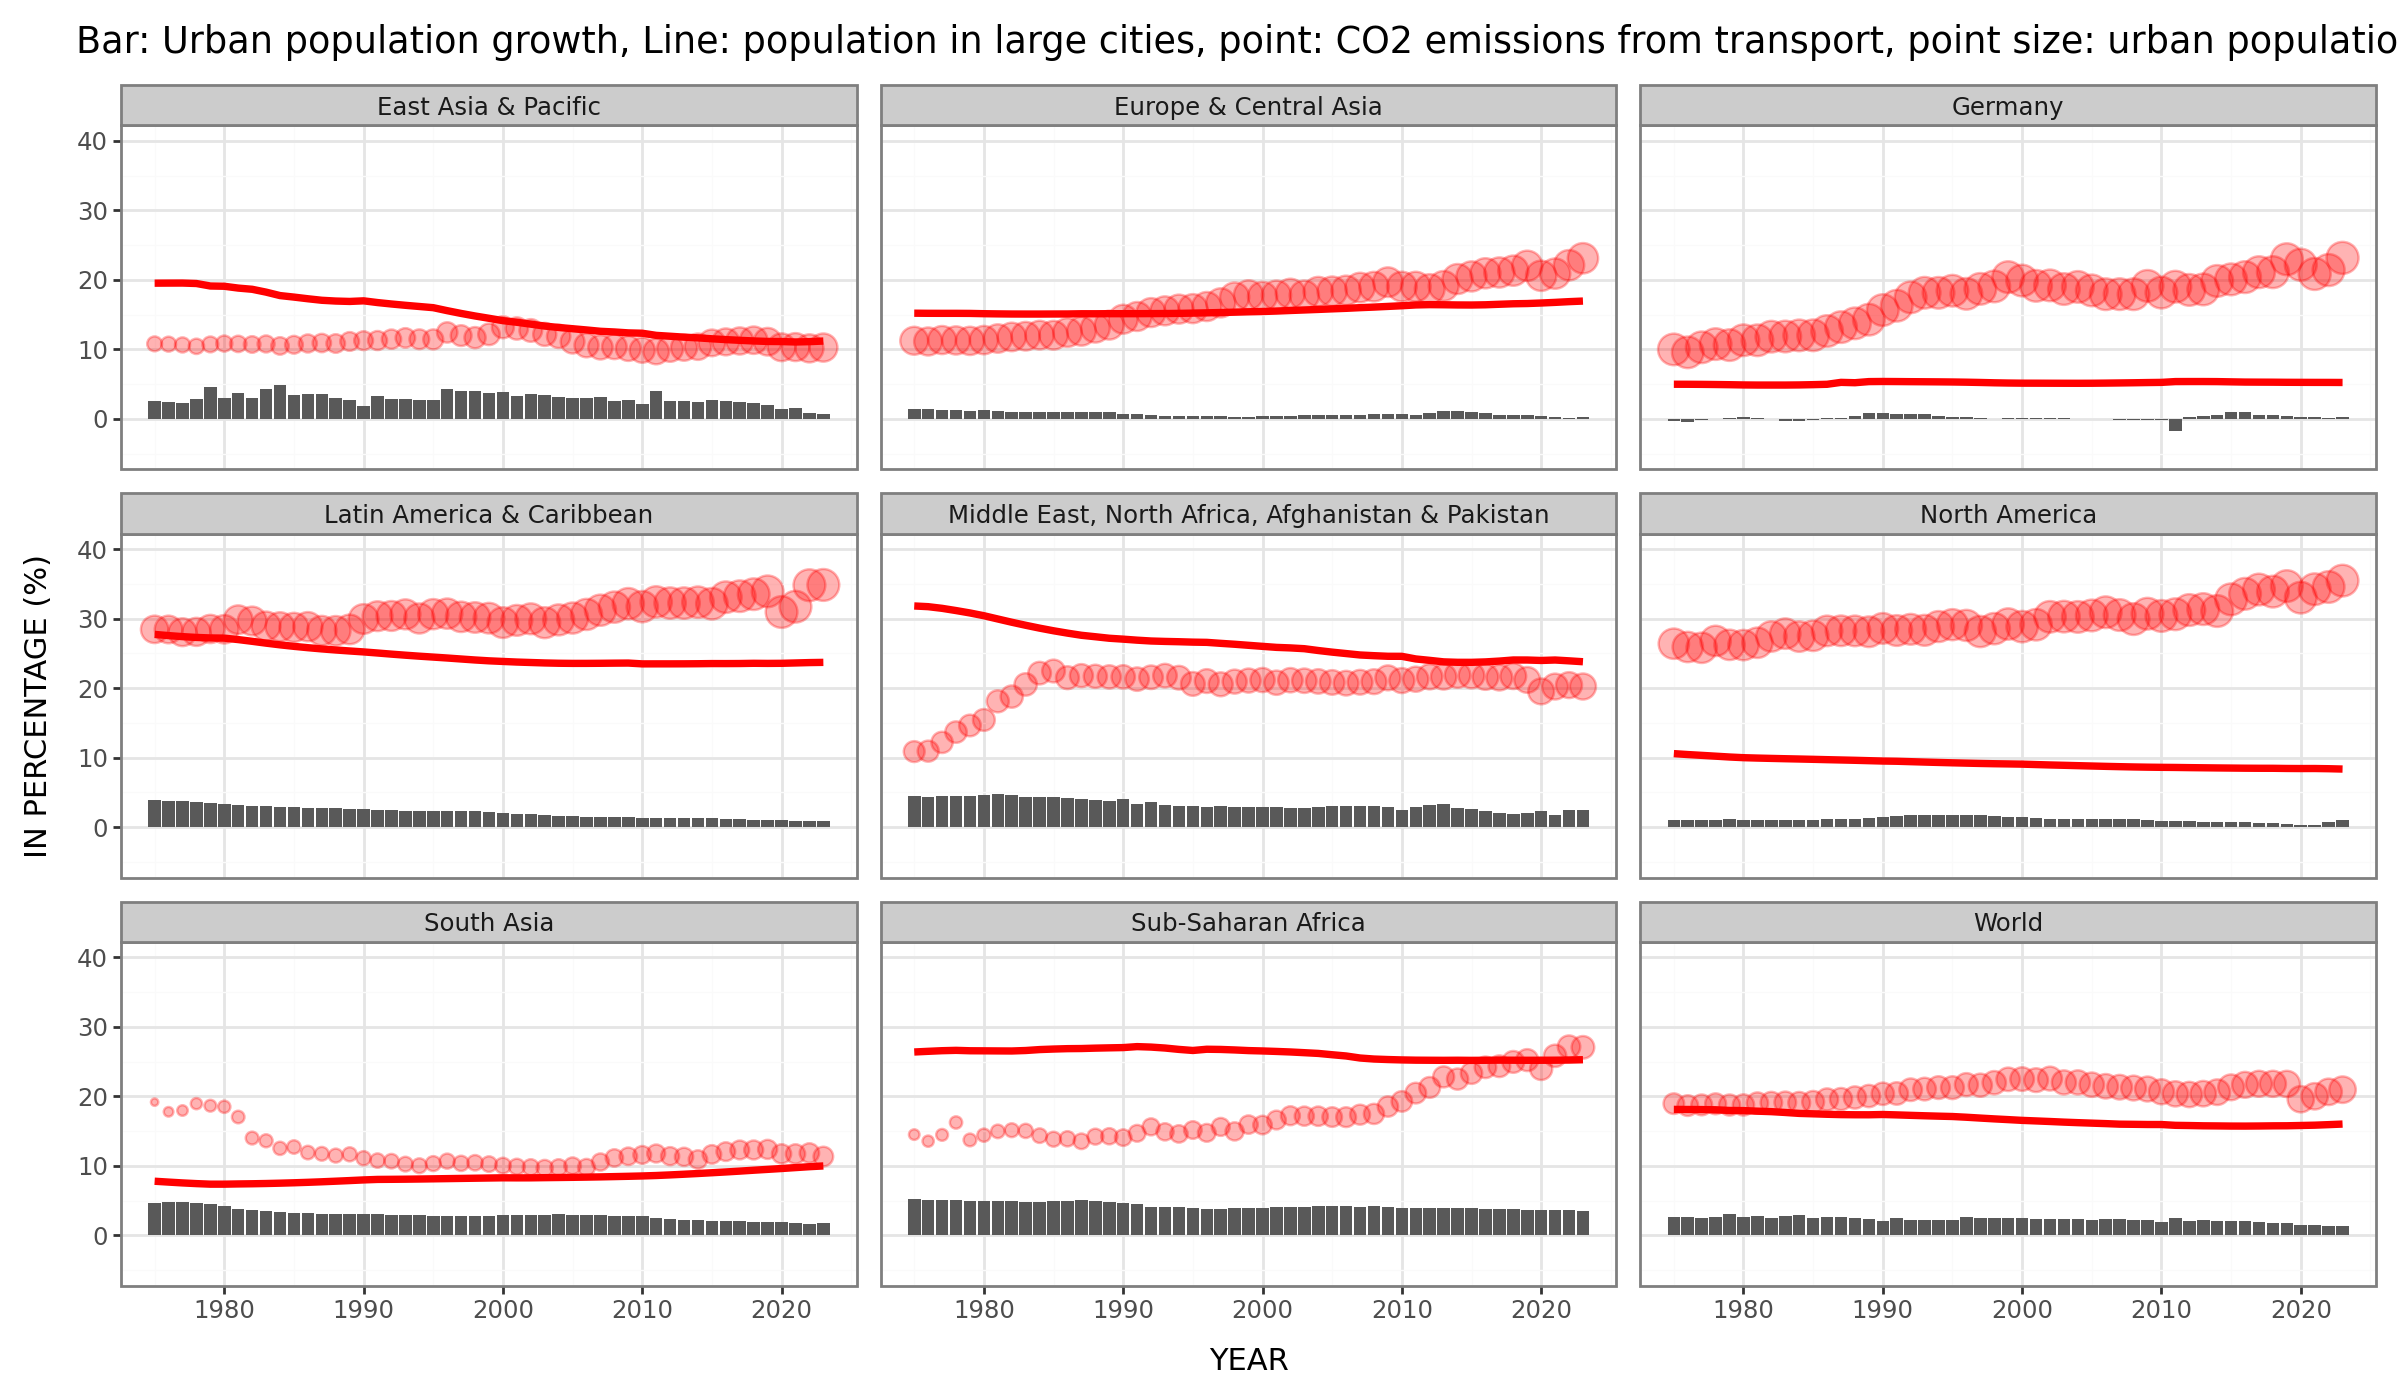

In [41]:


myplot = (
    ggplot()
    # Points: transport share, sized by urban population share.
    # colour and alpha sit OUTSIDE aes() - inside, they would be mapped, not set.
    + geom_point(panel,
                 aes(x="date", y="co2_transport_share", size="SP.URB.TOTL.IN.ZS"),
                 colour="red", alpha=0.3)
    # Line: population in the largest city
    + geom_line(panel, aes(x="date", y="EN.URB.LCTY.UR.ZS"),
                colour="red", size=1.5)
    # Bars: urban population growth
    + geom_col(panel, aes(x="date", y="SP.URB.GROW"))
    + labs(x="YEAR", y="IN PERCENTAGE (%)")
    # coord_cartesian() zooms; xlim()/ylim() would delete the edge-year bars.
    + coord_cartesian(xlim=(start_year, end_year), ylim=(-5, 40))
    + theme_bw()
    + ggtitle("Bar: Urban population growth, "
              "Line: population in large cities, "
              "point: CO2 emissions from transport, "
              "point size: urban population")
    + theme(legend_position="none", figure_size=(12, 7))
    + facet_wrap("~country")
)

myplot

### What does the figure show?

Germany urbanises slowly and its transport share of CO₂ climbs steadily. Sub-Saharan
Africa is the opposite: fast urban growth, and a transport share that only starts
rising recently.

The regional aggregates hide as much as they show, though — a region is not a
country. That is the reason for the second half of this chapter.

### One value for every country

For a map we need a single number per country. Countries do not all report in the
same year, so instead of fixing a year and blanking out everyone who reports late,
we take **the latest year each country actually reported**, and keep that year
alongside the value.

In [42]:
# mrnev=1  -> latest year each country actually reported
# skipAggs -> countries only, no regional aggregates
wide = wb.data.DataFrame(
    study_indicators, mrnev=1, skipAggs=True, labels=True,
    columns="series", timeColumns=True,
).reset_index()

# The same derived share as Part 1, so both views show the identical quantity.
wide["co2_transport_share"] = (
    100 * wide["EN.GHG.CO2.TR.MT.CE.AR5"] / wide["EN.GHG.CO2.MT.CE.AR5"]
)
wide["co2_transport_share:T"] = wide["EN.GHG.CO2.TR.MT.CE.AR5:T"]

print(wide.shape)
wide.head()

(217, 14)


,economy,Country,EN.GHG.CO2.MT.CE.AR5,EN.GHG.CO2.MT.CE.AR5:T,EN.GHG.CO2.TR.MT.CE.AR5,EN.GHG.CO2.TR.MT.CE.AR5:T,EN.URB.LCTY.UR.ZS,EN.URB.LCTY.UR.ZS:T,SP.URB.GROW,SP.URB.GROW:T,SP.URB.TOTL.IN.ZS,SP.URB.TOTL.IN.ZS:T,co2_transport_share,co2_transport_share:T
0,AFG,Afghanistan,12.0684,2024,4.3071,2024,42.881590,2025,3.694491,2025,25.940164,2025,35.689072,2024
1,ALB,Albania,4.2437,2024,1.5510,2024,38.728283,2025,-0.611904,2025,58.871474,2025,36.548295,2024
2,DZA,Algeria,186.3584,2024,48.6376,2024,8.352969,2025,2.031841,2025,75.818736,2025,26.098958,2024
3,ASM,American Samoa,0.0001,2024,NaN,NaN,NaN,NaN,-2.122542,2025,80.512351,2025,NaN,NaN
4,AND,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,1.244439,2025,88.949267,2025,NaN,NaN


### Pick an indicator to map

Change `INDICATOR` — that is the only line you need to touch.

In [36]:
INDICATORS = {
    # column                  : (legend title, single-hue colormap)
    "co2_transport_share":      ("Transport share of national CO2 (%)", "Reds"),
    "SP.URB.TOTL.IN.ZS":        ("Urban population (% of total)", "Blues"),
    "SP.URB.GROW":              ("Urban population growth (annual %)", "Purples"),
    "EN.URB.LCTY.UR.ZS":        ("Population in largest city (% of urban)", "Greens"),
    "EN.GHG.CO2.TR.MT.CE.AR5":  ("CO2 from transport (Mt CO2e)", "Reds"),
}

INDICATOR = "co2_transport_share"       # <- change this
LEGEND_TITLE, CMAP = INDICATORS[INDICATOR]

years = wide[f"{INDICATOR}:T"].dropna()
print(f"{LEGEND_TITLE}: {wide[INDICATOR].notna().sum()} countries reporting, "
      f"vintages {int(years.min())}-{int(years.max())}")

Transport share of national CO2 (%): 194 countries reporting, vintages 2024-2024


### 6. Adding geometry

Numbers join to country polygons. Which column you join on matters: Natural Earth
ships several ISO-like codes and they are not interchangeable. `ISO_A3` carries
`-99` for a handful of countries and would drop them without a word, so we use
`ADM0_A3` and patch three known spelling differences by hand.

The cell reports the two ways a country can end up grey — no match, or no value —
because they look identical on the map and need opposite fixes.

In [37]:
COUNTRIES_URL = (
    "https://github.com/opengeos/datasets/releases/download/vector/countries.geojson"
)
world = gpd.read_file(COUNTRIES_URL)

ALIASES = {"KOS": "XKX", "SDS": "SSD", "PSX": "PSE"}  # Kosovo, S. Sudan, Palestine
world["iso3"] = world["ADM0_A3"].replace(ALIASES)

gdf = world.merge(wide, left_on="iso3", right_on="economy", how="left")

# Grey countries have two very different causes. Keep them apart:
#   no match -> the join broke (6 entities the World Bank does not report on)
#   no value -> the join worked, the series is just empty there
no_match = sorted(gdf.loc[gdf["economy"].isna(), "NAME"])
no_value = sorted(gdf.loc[gdf["economy"].notna() & gdf[INDICATOR].isna(), "NAME"])

print(f"{gdf[INDICATOR].notna().sum()} of {len(gdf)} polygons carry a value")
print(f"  no World Bank match ({len(no_match)}): {no_match}")
print(f"  matched, but empty series ({len(no_value)}): {no_value}")

165 of 176 polygons carry a value
  no World Bank match (6): ['Falkland Is.', 'Fr. S. Antarctic Lands', 'N. Cyprus', 'Somaliland', 'Taiwan', 'W. Sahara']
  matched, but empty series (5): ['Kosovo', 'Montenegro', 'Palestine', 'S. Sudan', 'Serbia']


### The interactive globe

Grey for every country first, then the colours on top, so **no data looks like no
data** rather than like the bottom of the colour scale.

In [ ]:
NO_DATA_COLOR = "#d9d9d9"


def build_globe(data, indicator, legend_title, cmap, projection="globe",
                for_export=False):
    """The interactive globe. Built fresh for display and for export."""
    m = leafmap.Map(
        center=[10, 25], zoom=1.4, style="liberty",
        projection=projection,          # "mercator" for a flat map
        height="700px",
        use_message_queue=for_export,   # on for to_html(), off for display
        add_sidebar=False,              # the sidebar is an ipyvuetify widget
        add_floating_sidebar=False,     # that VS Code cannot draw
    )

    # Put our fills under the basemap labels, so place names stay readable.
    first_symbol = m.find_first_symbol_layer()
    before = first_symbol["id"] if first_symbol else None

    m.add_gdf(
        world, layer_type="fill", name="No data",
        paint={"fill-color": NO_DATA_COLOR, "fill-outline-color": "#ffffff"},
        fit_bounds=False, before_id=before,
    )
    m.add_data(
        data[data[indicator].notna()],
        column=indicator, cmap=cmap, scheme="Quantiles", k=5,
        legend_title=legend_title, name=legend_title,
        fit_bounds=False, before_id=before,
    )
    m.add_layer_control()
    return m


# Two ways to look at it:
#   plot_globe()  - static, renders anywhere
#   build_globe() - interactive, and exported in Step 4

**Spin it.** Drag to rotate, scroll to zoom, buttons to switch layers or go flat.

In [ ]:
build_globe(gdf, INDICATOR, LEGEND_TITLE, CMAP)

Here what you can expect to explore: 

![interactive-globe](/resources/interactive_globe_view_transport_indicator.gif)

### Try this

- **Flat map:** `projection="mercator"`, or click the globe button.
- **One region:** `gdf[gdf.REGION_WB == "Europe & Central Asia"]`.
- **3D:** add `extrude=True, scale_factor=20000` to `add_data()`. Looks great, reads badly.

### What does the map show?

The transport share of national CO₂ is highest across West and Central Africa —
not because those countries drive the most, but because they emit little from
anything else. Absolute transport emissions (try that indicator) put the same
countries at the bottom.

One indicator, two very different stories about the same places.

## Try it yourself

The data is live, so the notebook is a starting point rather than a result:

- Swap `INDICATOR` for another entry — does the pattern move with it?
- Add your own country next to Germany in Part 1.
- Map a single region: `gdf[gdf.REGION_WB == "Europe & Central Asia"]`.
- Find an indicator we did not use — the appendix below searches the catalogue.
- Ask whether a *share* or an *absolute* value answers your question better.

Reproducing a figure is the easy half. The interesting half is asking the data
something it was not originally asked.

## Part two

# using ioer data repo api

# country level point density visualization
# https://data.fdz.ioer.de/file.xhtml?fileId=6268&version=1.2

# city level stat
# https://data.fdz.ioer.de/file.xhtml?fileId=6215&version=1.2

# city level frequency eda
# https://github.com/ssujit/public_transit_germany/blob/main/jupyter_notebook/1_exploratory_data_analysis.ipynb
# https://github.com/ssujit/public_transit_germany/blob/main/jupyter_notebook/3_spatial_statistics_neighborhood.ipynb


## Conclusion

This chapter moves from:

**open API → verified indicators → regional trend → global map → shareable artefact**

Urbanisation and transport emissions are not one story but many, and which one you
see depends on whether you look at a region or a country, a share or a total.

Because everything here is fetched at run time and checked before use, the same
notebook re-run next year gives next year's answer — including a loud failure if
an indicator has been retired in the meantime.

## Appendix: browse the catalogue

Looking for a different indicator? `.list()` gives you dicts; wrap them in a
DataFrame and filter. `wb.series.list(q="urban")` searches.

In [ ]:
countries = pd.DataFrame(wb.economy.list())     # ~ wb_countries()
regions_df = pd.DataFrame(wb.region.list())     # ~ wb_regions()
topics = pd.DataFrame(wb.topic.list())          # ~ wb_topics()
series = pd.DataFrame(wb.series.list())         # ~ wb_indicators() (WDI only)

print(f"{len(countries)} economies, {len(regions_df)} regions, "
      f"{len(topics)} topics, {len(series)} indicators in WDI")
topics

## Notes

- **Map blank?** Restart the runtime and run all.